In [ ]:
!pip install "tensorflow[and-cuda]" pandas scikit-learn numpy matplotlib

In [1]:
import tensorflow as tf

In [77]:
from glob import glob

CAPUCHIN_FILES = glob("/content/drive/MyDrive/Datasets/data/Parsed_Capuchinbird_Clips/*.wav")
NOT_CAPUCHIN_FILES = glob("/content/drive/MyDrive/Datasets/data/Parsed_Not_Capuchinbird_Clips/*.wav")

In [ ]:
len(CAPUCHIN_FILES)

In [ ]:
len(NOT_CAPUCHIN_FILES)

## Joining both list of files and labelling them

In [80]:
capuchin_labels = [1] * len(CAPUCHIN_FILES)
not_capuchin_labels = [0] * len(NOT_CAPUCHIN_FILES)

labelled_capuchin_files = list(zip(CAPUCHIN_FILES, capuchin_labels))
labelled_not_capuchin_files = list(zip(NOT_CAPUCHIN_FILES, not_capuchin_labels))

In [ ]:
labelled_capuchin_files

In [ ]:
labelled_not_capuchin_files

In [81]:
import random

random.seed(42)

labelled_audio_files = labelled_capuchin_files + labelled_not_capuchin_files
random.shuffle(labelled_audio_files)

In [ ]:
len(labelled_audio_files)

## Split files into our initial train and test set

In [82]:
SPLIT_RATIO = 0.8
split_index = int(len(labelled_audio_files) * SPLIT_RATIO)

train_audio_files = labelled_audio_files[:split_index]
test_audio_files = labelled_audio_files[split_index:]

In [9]:
len(train_audio_files)

648

In [10]:
len(test_audio_files)

162

In [83]:
train_capuchin_files = [f for (f, label) in train_audio_files if label == 1]

In [84]:
len(train_capuchin_files)

176

In [85]:
len(train_audio_files) - len(train_capuchin_files)

472

## Getting the Min, Max and Mean duration of the capuchin calls recorded

In [ ]:
import os

durations = []
for filepath in train_capuchin_files:
    raw = tf.io.read_file(filepath)
    audio, sr = tf.audio.decode_wav(raw, desired_channels=1)
    duration_seconds = audio.shape[0] / sr.numpy()
    durations.append(duration_seconds)
    # print(f"{os.path.basename(filepath)}: {duration_seconds:.2f}s")

print(f"\nMin:  {min(durations):.2f}s")
print(f"Max:  {max(durations):.2f}s")
print(f"Mean: {sum(durations)/len(durations):.2f}s")


Min:  2.00s
Max:  5.00s
Mean: 3.39s


## Creating functions to play sounds and plot their graphs

In [ ]:
from IPython.display import Audio, display

def play_wav(file_path: str)-> None:
  """
  Plays the sound of the wav file
  """

  raw = tf.io.read_file(file_path)
  audio, sample_rate = tf.audio.decode_wav(raw, desired_channels=1)
  audio = tf.squeeze(audio, axis=1).numpy()
  sample_rate = sample_rate.numpy()

  display(Audio(data=audio, rate=sample_rate))

play_wav(train_capuchin_files[0])


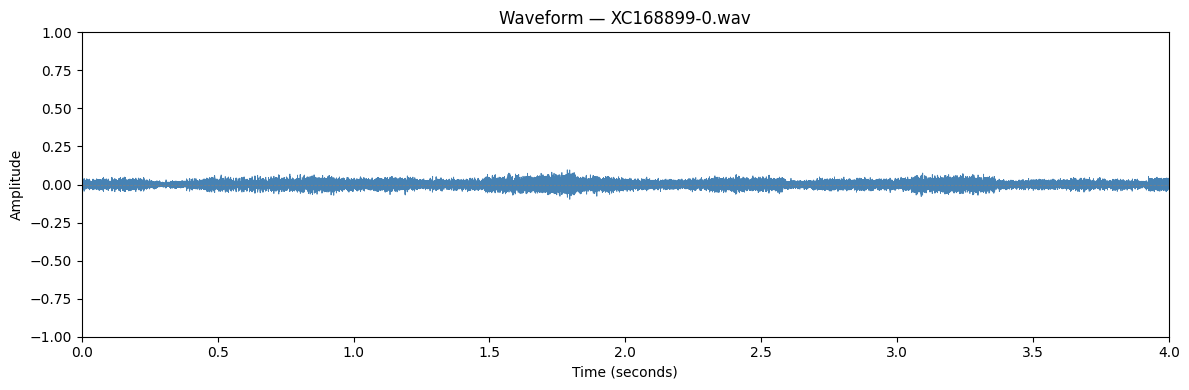

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_amplitude(file_path: str)-> None:
  """
  Function to plot the wave amplitude against time
  """
  # Load the audio using TF
  raw = tf.io.read_file(file_path)
  audio, sample_rate = tf.audio.decode_wav(raw, desired_channels=1)
  # Remove the extra dimension and convert to numpy array
  audio = tf.squeeze(audio, axis=-1).numpy()
  # Convert the smaple rate to numpy array as well
  sample_rate = sample_rate.numpy()

  # Build the time axis in seconds
  duration = len(audio) / sample_rate
  time_axis = np.linspace(0, duration, num=len(audio))

  # Plot
  plt.figure(figsize=(12, 4))
  plt.plot(time_axis, audio, color='steelblue', linewidth=0.6)
  plt.title(f"Waveform — {file_path.split('/')[-1]}")
  plt.xlabel("Time (seconds)")
  plt.ylabel("Amplitude")
  plt.xlim([0, duration])
  plt.ylim([-1.0, 1.0])          # WAV amplitude is always normalised to [-1, 1]
  plt.axhline(0, color='gray', linewidth=0.5, linestyle='--')
  plt.tight_layout()
  plt.show()

plot_amplitude(train_capuchin_files[0])

## Creating functions to generate and plot spectograms (Not fully CNN Optimized)

In [86]:
SAMPLING_RATE = 44100
MEAN_CAPUCHIN_CALL_DURATION = 3.5
TARGET_SAMPLES = int(SAMPLING_RATE * MEAN_CAPUCHIN_CALL_DURATION)

def load_wav(file_path:str) -> None:
  """
  Takes the file path of a wav file and returns its audio data and sampling rate
  """

  raw = tf.io.read_file(file_path)
  audio, sample_rate = tf.audio.decode_wav(
      raw,
      desired_channels=1,
      desired_samples=TARGET_SAMPLES)

  audio = tf.squeeze(audio, axis=-1)
  sample_rate = sample_rate.numpy()

  return (audio, sample_rate)

def get_spectogram(audio: tf.Tensor) -> tf.Tensor:

  # Compute STFT
  stft = tf.signal.stft(
      audio,
      frame_length = 1024,
      frame_step = 512,
      fft_length = 1024
  )

  # tf.abs(stft) — Why take the absolute value?
  # The STFT output is a complex number for each time-frequency bin. It has two components:
  # 1) Magnitude — how much energy is present at that frequency at that moment
  # 2) Phase — where in the wave cycle that frequency is
  # For Capuchin call recognition, phase carries almost no useful information — what identifies a call is which frequencies are active and when, not the phase of each wave. Taking the absolute value extracts just the magnitude, which is what your CNN needs to learn from.
  # Without it, you'd be feeding complex numbers into the network, which TensorFlow's CNN layers can't process directly.
  spectogram = tf.abs(stft)

  # Add a tiny constant to prevent log(0)
  log_spectogram = tf.math.log(spectogram + 1e-6)

  return log_spectogram

In [ ]:
def plot_log_spec(file_path:str, log_spectrogram)-> None:
  plt.figure(figsize=(12, 5))
  plt.imshow(
      tf.transpose(log_spectrogram).numpy(),  # transpose so time is on x-axis
      aspect='auto',
      origin='lower',
      cmap='magma'
  )
  plt.colorbar(label='Log Magnitude')
  plt.title(f"Spectrogram — {file_path.split('/')[-1]}")
  plt.xlabel("Time Frames")
  plt.ylabel("Frequency Bins")
  plt.tight_layout()
  plt.show()

## Testing all graphing functions created

In [ ]:
file_path = train_capuchin_files[0]

play_wav(file_path)

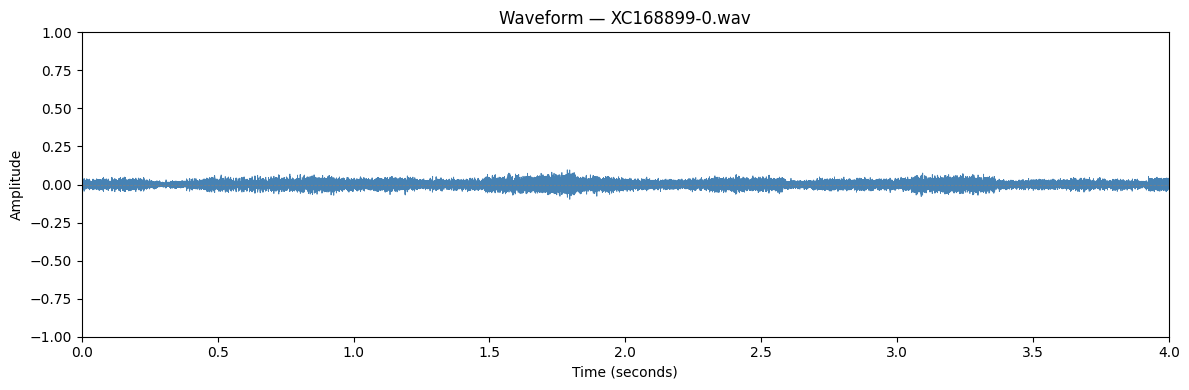

In [ ]:
plot_amplitude(file_path)

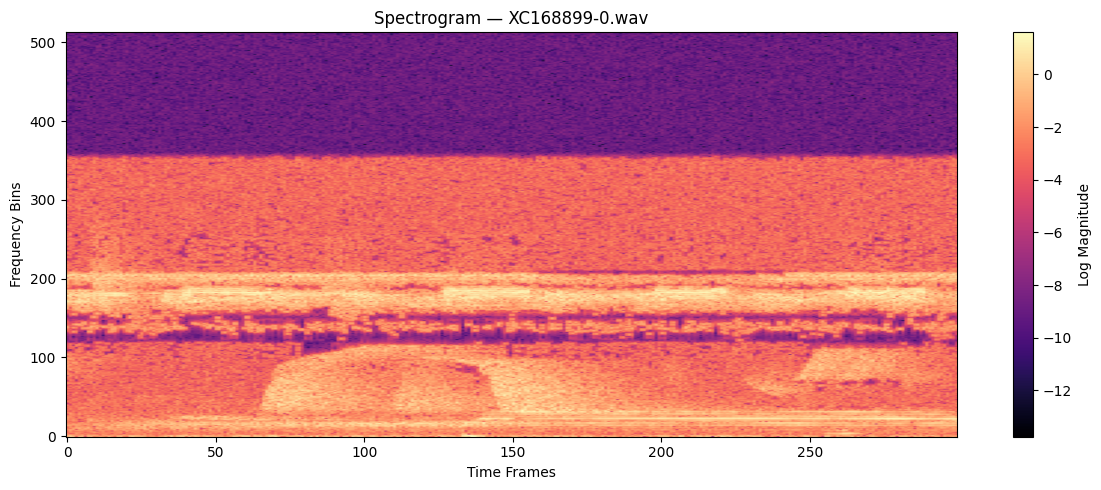

In [ ]:
(audio, sr) = load_wav(file_path)
spec = get_spectogram(audio)
plot_log_spec(file_path, spec)

In [ ]:
spec

<tf.Tensor: shape=(300, 513), dtype=float32, numpy=
array([[ -1.1533368 ,  -0.4606668 ,  -1.7925814 , ...,  -9.9950905 ,
         -9.316381  ,  -9.252148  ],
       [  0.2771792 ,   0.04513781,  -1.1245213 , ...,  -8.281995  ,
         -9.017801  , -10.214272  ],
       [ -0.35764298,  -0.5664097 ,  -2.0882397 , ...,  -8.477623  ,
         -8.816236  ,  -9.209116  ],
       ...,
       [ -1.7391306 ,  -1.5215292 ,  -1.8062887 , ...,  -8.592884  ,
         -9.997254  ,  -8.318187  ],
       [ -1.0434859 ,  -1.4596853 ,  -2.4436915 , ...,  -8.301405  ,
         -9.012975  , -10.840152  ],
       [ -1.7591852 ,  -1.3170798 ,  -2.3456206 , ...,  -9.021403  ,
         -8.883076  ,  -9.989919  ]], dtype=float32)>

## Data Augmentation Step

In [87]:
def amplitude_scaling(audio: tf.Tensor, min_factor=0.7, max_factor=1.3) -> tf.Tensor:
  """
  Randomly scales the amplitude of the audio signal
  Simulates the animal calling from varying distance
  """
  factor = tf.random.uniform([], min_factor, max_factor)
  audio = audio * factor
  return audio

def time_mask(log_spec: tf.Tensor, num_masks=2, max_mask_size=30) -> tf.Tensor:
  time_steps = log_spec.shape[0]
  freq_bins  = log_spec.shape[1]
  fill_value = tf.reduce_min(log_spec)  # ← silence in log scale

  for _ in range(num_masks):
      t  = tf.random.uniform([], 10, max_mask_size, dtype=tf.int32)
      t0 = tf.random.uniform([], 0, time_steps - max_mask_size, dtype=tf.int32)

      indices = tf.range(time_steps)
      mask    = tf.logical_or(indices < t0, indices >= t0 + t)
      mask    = tf.cast(mask, tf.float32)
      mask    = tf.expand_dims(mask, axis=1)
      mask    = tf.tile(mask, [1, freq_bins])

      # Apply: keep original where mask=1, fill_value where mask=0
      log_spec = tf.where(mask == 1.0, log_spec, tf.fill(tf.shape(log_spec), fill_value))

  return log_spec


def frequency_mask(log_spec: tf.Tensor, num_masks=2, max_mask_size=30) -> tf.Tensor:
  time_steps = log_spec.shape[0]
  freq_bins  = log_spec.shape[1]
  fill_value = tf.reduce_min(log_spec)  # ← silence in log scale

  for _ in range(num_masks):
      f  = tf.random.uniform([], 10, max_mask_size, dtype=tf.int32)
      # Instead of masking the full 0-513 range,
      # restrict to the frequency bins that actually contain call information
      f0 = tf.random.uniform([], 0, 250 - max_mask_size, dtype=tf.int32)  # stay below bin 250 as most energetic frequencies are found there.

      indices = tf.range(freq_bins)
      mask    = tf.logical_or(indices < f0, indices >= f0 + f)
      mask    = tf.cast(mask, tf.float32)
      mask    = tf.expand_dims(mask, axis=0)
      mask    = tf.tile(mask, [time_steps, 1])

      log_spec = tf.where(mask == 1.0, log_spec, tf.fill(tf.shape(log_spec), fill_value))

  return log_spec

In [88]:
def augment_capuchin(capuchin_path: str, amplitude_range: tuple = (0.7,1.3)) -> list:
  audio, _ = load_wav(capuchin_path)

  # Amplitude scaling
  augmented_audio = amplitude_scaling(audio, *amplitude_range)

  # Convert to log spectogram
  log_spec = get_spectogram(augmented_audio)

  # SpecAugment
  log_spec = time_mask(log_spec)
  log_spec = frequency_mask(log_spec)

  return log_spec

In [ ]:
augmented_spec = augment_capuchin(file_path)

plot_log_spec(file_path, augmented_spec)

In [ ]:
augmented_spec

In [ ]:
def is_valid_augmentation(log_spec: tf.Tensor, max_masked_pct=0.50) -> bool:
    """
    Returns False if more than 20% of the spectrogram is masked.
    """
    fill_value   = tf.reduce_min(log_spec)
    masked_count = tf.reduce_sum(tf.cast(tf.abs(log_spec - fill_value) < 1e-5, tf.int32))
    total        = tf.cast(tf.size(log_spec), tf.int32)
    masked_pct   = tf.cast(masked_count, tf.float32) / tf.cast(total, tf.float32)
    return masked_pct.numpy() < max_masked_pct

def build_augmented_capuchin_files():
  number_of_loops = ((len(train_audio_files) - len(train_capuchin_files)) // len(train_capuchin_files)) + 1

  augmented_train_capuchin_specs = list()
  rejected = 0

  for _ in range(number_of_loops):
    for file_path in train_capuchin_files:
      spec = augment_capuchin(file_path)
      if is_valid_augmentation(spec):
          augmented_train_capuchin_specs.append(spec)
      else:
          rejected += 1

  print(f"Accepted: {len(augmented_train_capuchin_specs)}")
  print(f"Rejected: {rejected}")
  return augmented_train_capuchin_specs

augmented_split_index = (len(train_audio_files) - len(train_capuchin_files))
augmented_train_specs = (build_augmented_capuchin_files())[:augmented_split_index]

In [ ]:
augmented_train_specs

In [18]:
len(augmented_train_specs)

472

In [ ]:
for i in range ((len(augmented_train_specs) // 10)):
  testing_augmented_spec = augmented_train_specs[i]

  plot_log_spec(f"Test {i+1}", testing_augmented_spec)

## Comparing the original spectogram to the augmented spectogram

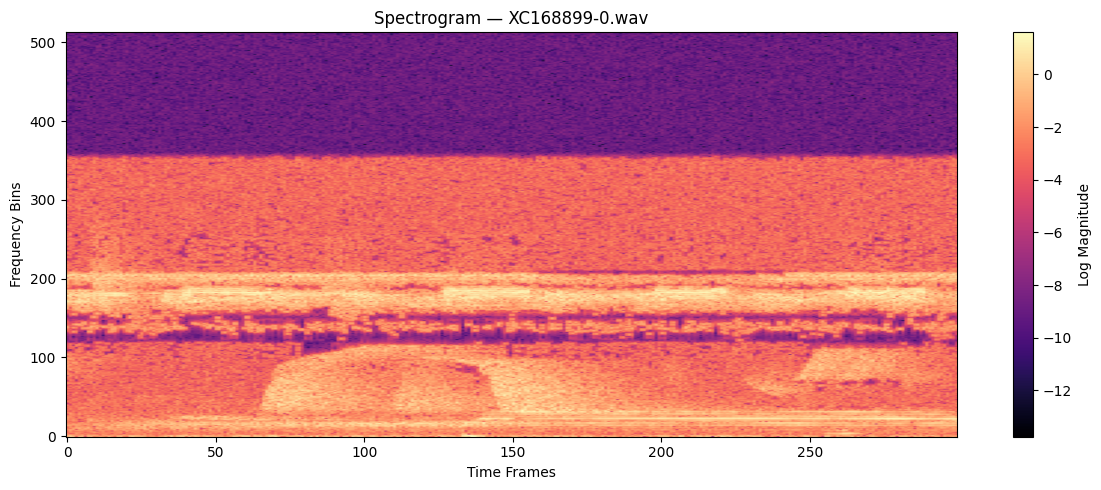

In [ ]:
(audio, sr) = load_wav(train_capuchin_files[0])
spec = get_spectogram(audio)
plot_log_spec(file_path, spec)

In [ ]:
spec

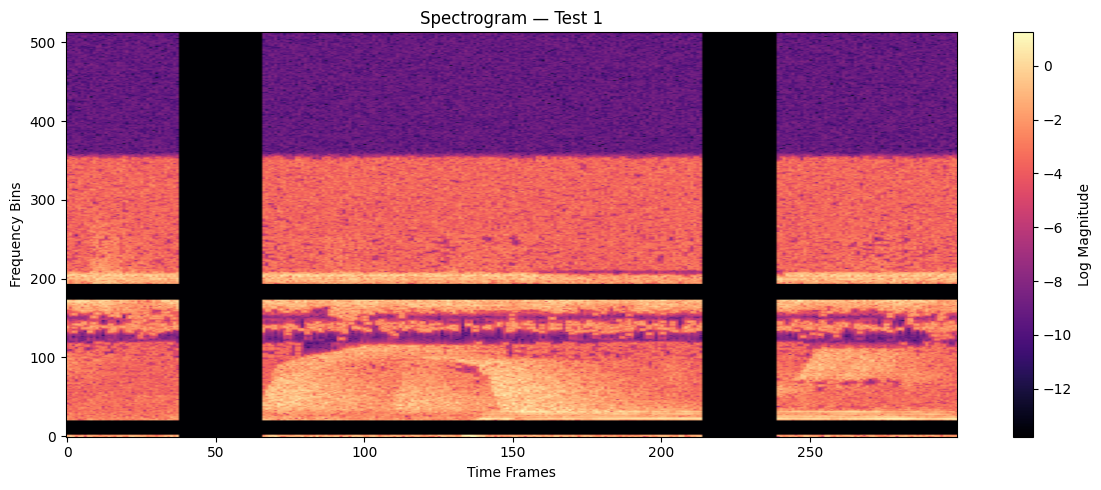

In [ ]:
test_augmented_spec = augmented_train_specs[0]

plot_log_spec("Test 1", test_augmented_spec)

In [ ]:
test_augmented_spec

## Creating our training and validation dataset

In [90]:
SAMPLING_RATE = 44100
MEAN_CAPUCHIN_CALL_DURATION = 3.5
TARGET_SAMPLES = int(SAMPLING_RATE * MEAN_CAPUCHIN_CALL_DURATION)

def CNN_load_wav(file_path:str) -> None:
  """
  Takes the file path of a wav file and returns its audio data and sampling rate
  """

  raw = tf.io.read_file(file_path)
  audio, sample_rate = tf.audio.decode_wav(
      raw,
      desired_channels=1,
      desired_samples=TARGET_SAMPLES)

  audio = tf.squeeze(audio, axis=-1)

  return audio

def CNN_get_spectogram(audio: tf.Tensor) -> tf.Tensor:

  # Compute STFT
  stft = tf.signal.stft(
      audio,
      frame_length = 1024,
      frame_step = 512,
      fft_length = 1024
  )

  # tf.abs(stft) — Why take the absolute value?
  # The STFT output is a complex number for each time-frequency bin. It has two components:
  # 1) Magnitude — how much energy is present at that frequency at that moment
  # 2) Phase — where in the wave cycle that frequency is
  # For Capuchin call recognition, phase carries almost no useful information — what identifies a call is which frequencies are active and when, not the phase of each wave. Taking the absolute value extracts just the magnitude, which is what your CNN needs to learn from.
  # Without it, you'd be feeding complex numbers into the network, which TensorFlow's CNN layers can't process directly.
  spectogram = tf.abs(stft)

  # Add a tiny constant to prevent log(0)
  log_spectogram = tf.math.log(spectogram + 1e-6)

  # Add the extra dimension for CNN
  log_spectogram =  tf.expand_dims(log_spectogram, axis=-1)

  return log_spectogram

In [91]:
def generate_spec_from_file_path(file_path:str, label: int) -> tf.Tensor:
  audio = CNN_load_wav(file_path)
  spec = CNN_get_spectogram(audio)

  return (spec, label)

unaugmented_train_files, unaugmented_train_files_labels = zip(*train_audio_files)

unaugmented_train_ds = tf.data.Dataset.from_tensor_slices((list(unaugmented_train_files), list(unaugmented_train_files_labels)))

# Now map correctly
unaugmented_train_ds = unaugmented_train_ds.map(
    lambda file_path, label: generate_spec_from_file_path(file_path, label),
    num_parallel_calls=tf.data.AUTOTUNE
)

unaugmented_train_ds

<_ParallelMapDataset element_spec=(TensorSpec(shape=(300, 513, 1), dtype=tf.float32, name=None), TensorSpec(shape=(), dtype=tf.int32, name=None))>

In [92]:
def CNN_augment_capuchin(capuchin_path: str, amplitude_range: tuple = (0.7,1.3)) -> list:
  audio = CNN_load_wav(capuchin_path)

  # Amplitude scaling
  augmented_audio = amplitude_scaling(audio, *amplitude_range)

  # Convert to log spectogram
  log_spec = get_spectogram(augmented_audio)

  # SpecAugment
  log_spec = time_mask(log_spec)
  log_spec = frequency_mask(log_spec)

  # Add the extra dimension for CNN
  log_spec =  tf.expand_dims(log_spec, axis=-1)

  return log_spec

In [ ]:
def is_valid_augmentation(log_spec: tf.Tensor, max_masked_pct=0.50) -> bool:
    """
    Returns False if more than 20% of the spectrogram is masked.
    """
    fill_value   = tf.reduce_min(log_spec)
    masked_count = tf.reduce_sum(tf.cast(tf.abs(log_spec - fill_value) < 1e-5, tf.int32))
    total        = tf.cast(tf.size(log_spec), tf.int32)
    masked_pct   = tf.cast(masked_count, tf.float32) / tf.cast(total, tf.float32)
    return masked_pct.numpy() < max_masked_pct

def CNN_build_augmented_capuchin_files():
  number_of_loops = ((len(train_audio_files) - len(train_capuchin_files)) // len(train_capuchin_files)) + 1

  augmented_train_capuchin_specs = list()
  rejected = 0

  for _ in range(number_of_loops):
    for file_path in train_capuchin_files:
      spec = CNN_augment_capuchin(file_path)
      if is_valid_augmentation(spec):
          augmented_train_capuchin_specs.append(spec)
      else:
          rejected += 1

  print(f"Accepted: {len(augmented_train_capuchin_specs)}")
  print(f"Rejected: {rejected}")

  return augmented_train_capuchin_specs

augmented_split_index = (len(train_audio_files) - len(train_capuchin_files))
CNN_augmented_train_specs = (CNN_build_augmented_capuchin_files())[:augmented_split_index]

augmented_train_labels = [1] * len(CNN_augmented_train_specs)

CNN_augmented_train_data = list(zip(CNN_augmented_train_specs, augmented_train_labels))

CNN_augmented_train_data

In [94]:
stacked_augmented_specs = tf.stack(CNN_augmented_train_specs)

augmented_train_ds = tf.data.Dataset.from_tensor_slices((
    stacked_augmented_specs,
    augmented_train_labels
))

full_train_ds = unaugmented_train_ds.concatenate(augmented_train_ds)

# Shuffle before splitting
full_train_ds = full_train_ds.shuffle(buffer_size=1000, seed=42)

# Calculate sizes
total_train = sum(1 for _ in full_train_ds)
val_size    = int(total_train * 0.15)
train_size  = total_train - val_size

print(f"Total samples : {total_train}")
print(f"Train samples : {train_size}")
print(f"Val samples   : {val_size}")

# Split
val_ds   = full_train_ds.take(val_size).batch(32).prefetch(tf.data.AUTOTUNE)
train_ds = full_train_ds.skip(val_size).batch(32).prefetch(tf.data.AUTOTUNE)

Total samples : 1120
Train samples : 952
Val samples   : 168


## Adding Class Weights (Optional)

In [ ]:
n_total     = total_train
n_positive  = sum(1 for _, label in full_train_ds if label.numpy() == 1)
n_negative  = n_total - n_positive

weight_for_0 = n_total / (2 * n_negative)
weight_for_1 = n_total / (2 * n_positive)

class_weights = {0: weight_for_0, 1: weight_for_1}
print(f"Class weights: {class_weights}")

Class weights: {0: 1.1864406779661016, 1: 0.8641975308641975}


In [95]:
train_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 300, 513, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [96]:
val_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 300, 513, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [97]:
test_ds_files, test_ds_labels = zip(*test_audio_files)

len(test_ds_labels)

162

In [98]:
test_audio_files_ds = tf.data.Dataset.from_tensor_slices((list(test_ds_files), list(test_ds_labels)))

test_ds = test_audio_files_ds.map(
    lambda file_path, label: generate_spec_from_file_path(file_path, label),
    num_parallel_calls=tf.data.AUTOTUNE
)

test_ds

<_ParallelMapDataset element_spec=(TensorSpec(shape=(300, 513, 1), dtype=tf.float32, name=None), TensorSpec(shape=(), dtype=tf.int32, name=None))>

# Building the model for server

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dropout, Dense, MaxPooling2D, Conv2D, Normalization, BatchNormalization, Resizing

norm_layer = Normalization(axis=None) # global mean and variance
norm_layer.adapt(data=full_train_ds.map(map_func=lambda spec, label: spec))

cnn = Sequential([
    # Input layer
    Input(shape=(300,513,1)),

    # Normalization layer
    norm_layer,

    Conv2D(filters=32, kernel_size=(3,3), activation='relu', padding="same"),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(filters=64, kernel_size=(3,3), activation='relu', padding="same"),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # Conv2D(128, (3,3), activation='relu', padding='same'),
    # BatchNormalization(),
    # MaxPooling2D((2,2)),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.25),
    Dense(1, activation='sigmoid')

])

In [125]:
cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.000001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

In [ ]:
cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=16,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        )
    ]
)

In [32]:
from sklearn.metrics import classification_report
import numpy as np

test_ds_batched  = test_ds.batch(32).prefetch(tf.data.AUTOTUNE)

y_pred_probs = cnn.predict(test_ds_batched, verbose=0)
y_true = np.concatenate([label.numpy() for _, label in test_ds_batched])

for threshold in [0.35]:
  y_pred = (y_pred_probs > threshold).astype(int).flatten()
  print(f"\nThreshold: {threshold}")
  print(classification_report(
      y_true,
      y_pred,
      target_names=['Not Capuchin', 'Capuchin']
  ))


Threshold: 0.35
              precision    recall  f1-score   support

Not Capuchin       0.00      0.00      0.00       121
    Capuchin       0.25      1.00      0.40        41

    accuracy                           0.25       162
   macro avg       0.13      0.50      0.20       162
weighted avg       0.06      0.25      0.10       162



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


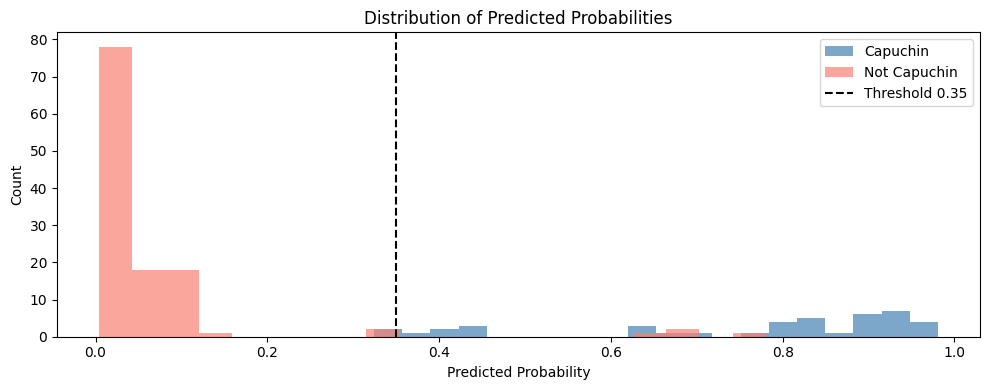

Probabilities of missed Capuchin calls: [0.32427788]


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.hist(y_pred_probs[y_true == 1], bins=20, alpha=0.7, label='Capuchin', color='steelblue')
plt.hist(y_pred_probs[y_true == 0], bins=20, alpha=0.7, label='Not Capuchin', color='salmon')
plt.axvline(x=0.35, color='black', linestyle='--', label='Threshold 0.35')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.title('Distribution of Predicted Probabilities')
plt.legend()
plt.tight_layout()
plt.show()

missed_calls = y_pred_probs[(y_true == 1) & ((y_pred_probs > 0.35).astype(int).flatten() == 0)]
print(f"Probabilities of missed Capuchin calls: {missed_calls.flatten()}")

## Saving the model

In [ ]:
cnn.save("/content/drive/MyDrive/models/capuchin_detector_final_2.keras")

## Convert the model to TFLite

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(cnn)
tflite_model = converter.convert()

# Save the TFLite model
with open('/content/drive/MyDrive/models/capuchin_detector_2.tflite', 'wb') as f:
    f.write(tflite_model)

print(f"TFLite model size: {len(tflite_model) / 1024:.2f} KB")

Saved artifact at '/tmp/tmpqj69c2fu'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 300, 513, 1), dtype=tf.float32, name='keras_tensor_51')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  136784831755472: TensorSpec(shape=(1, 1, 1), dtype=tf.float32, name=None)
  136784831755088: TensorSpec(shape=(1, 1, 1), dtype=tf.float32, name=None)
  136784831756432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136784831755664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136784831756048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136784831757392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136784831757200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136784831756624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136784831757008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136784831758160: TensorSpec(shape=(), dtype=tf.resource, name=None)
 

## Trying to check the mean inference time

In [51]:
import time
import numpy as np

interpreter = tf.lite.Interpreter(model_path='/content/drive/MyDrive/models/capuchin_detector_2.tflite')
interpreter.allocate_tensors()

input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

sample_input = np.random.rand(1, 300, 513, 1).astype(np.float32)
inference_times = []

for _ in range(50):
    start = time.perf_counter()
    interpreter.set_tensor(input_details[0]['index'], sample_input)
    interpreter.invoke()
    end = time.perf_counter()
    inference_times.append(end - start)

print(f"Mean inference time : {np.mean(inference_times) * 1000:.2f} ms")
print(f"Max inference time  : {np.max(inference_times) * 1000:.2f} ms")

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Mean inference time : 112.53 ms
Max inference time  : 201.99 ms


# Building the model for Raspberry Pi

In [63]:
#######################################################################
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dropout, Dense, MaxPooling2D, Conv2D, Normalization, BatchNormalization, Resizing

norm_layer = Normalization(axis=None) # global mean and variance
norm_layer.adapt(data=full_train_ds.map(map_func=lambda spec, label: spec))

cnn = Sequential([
    # Input layer
    Input(shape=(300,513,1)),

    # Resizing layer
    Resizing(128,128),

    # Normalization layer
    norm_layer,

    # Conv2D(filters=32, kernel_size=(3,3), activation='relu', padding="same"),
    # BatchNormalization(),
    # MaxPooling2D((2,2)),

    Conv2D(filters=16, kernel_size=(3,3), activation='relu', padding="same"),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(filters=32, kernel_size=(3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(32, activation='relu'),
    Dropout(0.5),
    # Dense(32, activation='relu'),
    # Dropout(0.2),
    Dense(1, activation='sigmoid')

])

In [64]:
#############################################################
cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

In [65]:
cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        )
    ]
)

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 332ms/step - accuracy: 0.7899 - loss: 0.4641 - precision: 0.8099 - recall: 0.8333 - val_accuracy: 0.7857 - val_loss: 0.5119 - val_precision: 0.7333 - val_recall: 1.0000
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 198ms/step - accuracy: 0.9496 - loss: 0.1419 - precision: 0.9589 - recall: 0.9555 - val_accuracy: 0.9107 - val_loss: 0.4474 - val_precision: 0.8526 - val_recall: 0.9878
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 19s 209ms/step - accuracy: 0.9716 - loss: 0.0862 - precision: 0.9783 - recall: 0.9731 - val_accuracy: 0.9643 - val_loss: 0.3751 - val_precision: 0.9490 - val_recall: 0.9894
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 22s 200ms/step - accuracy: 0.9779 - loss: 0.0741 - precision: 0.9769 - recall: 0.9856 - val_accuracy: 0.9762 - val_loss: 0.3132 - val_precision: 0.9900 - val_recall: 0.9706
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 16s 378ms/step - accuracy: 0.9790 - loss: 0.0626 - precision: 0.9834 - recall: 0.9798 - val_accuracy: 0.9940 - val_los

In [68]:
from sklearn.metrics import classification_report
import numpy as np

test_ds_batched  = test_ds.batch(32).prefetch(tf.data.AUTOTUNE)
threshold = 0.45

y_pred_probs = cnn.predict(test_ds_batched, verbose=0)
y_true = np.concatenate([label.numpy() for _, label in test_ds_batched])


y_pred = (y_pred_probs > threshold).astype(int).flatten()
print(f"\nThreshold: {threshold}")
print(classification_report(
    y_true,
    y_pred,
    target_names=['Not Capuchin', 'Capuchin']
))


Threshold: 0.45
              precision    recall  f1-score   support

Not Capuchin       1.00      0.98      0.99       121
    Capuchin       0.93      1.00      0.96        41

    accuracy                           0.98       162
   macro avg       0.97      0.99      0.98       162
weighted avg       0.98      0.98      0.98       162



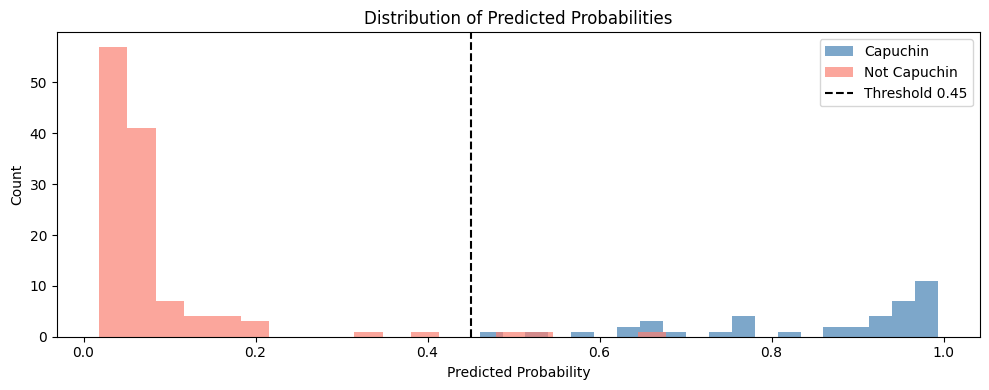

Probabilities of missed Capuchin calls: []


In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.hist(y_pred_probs[y_true == 1], bins=20, alpha=0.7, label='Capuchin', color='steelblue')
plt.hist(y_pred_probs[y_true == 0], bins=20, alpha=0.7, label='Not Capuchin', color='salmon')
plt.axvline(x=threshold, color='black', linestyle='--', label=f'Threshold {threshold}')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.title('Distribution of Predicted Probabilities')
plt.legend()
plt.tight_layout()
plt.show()

missed_calls = y_pred_probs[(y_true == 1) & ((y_pred_probs > 0.35).astype(int).flatten() == 0)]
print(f"Probabilities of missed Capuchin calls: {missed_calls.flatten()}")

## Save the pruned model

In [70]:
cnn.save("/content/drive/MyDrive/models/resized_capuchin_detector_final.keras")

## Convert to TFLite and get the size

In [71]:
converter = tf.lite.TFLiteConverter.from_keras_model(cnn)
tflite_model = converter.convert()

with open('/content/drive/MyDrive/models/resized_capuchin_detector.tflite', 'wb') as f:
    f.write(tflite_model)

print(f"TFLite model size: {len(tflite_model) / (1024*1024):.2f} MB")

Saved artifact at '/tmp/tmpj319iue0'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 300, 513, 1), dtype=tf.float32, name='keras_tensor_135')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  139931183067600: TensorSpec(shape=(1, 1, 1), dtype=tf.float32, name=None)
  139931183068368: TensorSpec(shape=(1, 1, 1), dtype=tf.float32, name=None)
  139931183059344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139931183064720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139931183067984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139931183069904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139931183068176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139931183068944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139931183069328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139931183067216: TensorSpec(shape=(), dtype=tf.resource, name=None)


## Check new inference time

In [73]:
import time
import numpy as np

interpreter = tf.lite.Interpreter(model_path='/content/drive/MyDrive/models/resized_capuchin_detector.tflite')
interpreter.allocate_tensors()

input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

sample_input   = np.random.rand(1, 300, 513, 1).astype(np.float32)
inference_times = []

for _ in range(50):
    start = time.perf_counter()
    interpreter.set_tensor(input_details[0]['index'], sample_input)
    interpreter.invoke()
    end = time.perf_counter()
    inference_times.append(end - start)

print(f"Mean inference time : {np.mean(inference_times) * 1000:.2f} ms")
print(f"Max inference time  : {np.max(inference_times) * 1000:.2f} ms")

Mean inference time : 7.67 ms
Max inference time  : 20.84 ms
